###Annika Timermanis

ID: 40131128

COMP 333 - Lab Assignment 1

Analyze data from tipping example, using CSV file data on factors that affect tip at a restaurant

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# from google.colab import drive
# drive.mount('/content/gdrive')

Importing tips.csv dataset

In [61]:
tip_data = pd.read_csv('./tips.csv')
tip_data = tip_data.drop(['Unnamed: 0'], axis=1)

In [62]:
# TIP RATE : (tip rate) = 0.18 - 0.01 × (party size)
tip_rate = 0.18 - 0.01 * tip_data['size']
tip_data['tip_rate'] = tip_rate

print(tip_data)

     total_bill   tip     sex smoker   day    time  size  tip_rate
0         16.99  1.01  Female     No   Sun  Dinner     2      0.16
1         10.34  1.66    Male     No   Sun  Dinner     3      0.15
2         21.01  3.50    Male     No   Sun  Dinner     3      0.15
3         23.68  3.31    Male     No   Sun  Dinner     2      0.16
4         24.59  3.61  Female     No   Sun  Dinner     4      0.14
..          ...   ...     ...    ...   ...     ...   ...       ...
239       29.03  5.92    Male     No   Sat  Dinner     3      0.15
240       27.18  2.00  Female    Yes   Sat  Dinner     2      0.16
241       22.67  2.00    Male    Yes   Sat  Dinner     2      0.16
242       17.82  1.75    Male     No   Sat  Dinner     2      0.16
243       18.78  3.00  Female     No  Thur  Dinner     2      0.16

[244 rows x 8 columns]


In [45]:
tip_data.head(10)

,total_bill,tip,sex,smoker,day,time,size,tip_rate
0,16.99,1.01,Female,No,Sun,Dinner,2,0.16
1,10.34,1.66,Male,No,Sun,Dinner,3,0.15
2,21.01,3.50,Male,No,Sun,Dinner,3,0.15
3,23.68,3.31,Male,No,Sun,Dinner,2,0.16
4,24.59,3.61,Female,No,Sun,Dinner,4,0.14
5,25.29,4.71,Male,No,Sun,Dinner,4,0.14
6,8.77,2.00,Male,No,Sun,Dinner,2,0.16
7,26.88,3.12,Male,No,Sun,Dinner,4,0.14
8,15.04,1.96,Male,No,Sun,Dinner,2,0.16
9,14.78,3.23,Male,No,Sun,Dinner,2,0.16


In [46]:
tip_data.tail(10)

,total_bill,tip,sex,smoker,day,time,size,tip_rate
234,15.53,3.00,Male,Yes,Sat,Dinner,2,0.16
235,10.07,1.25,Male,No,Sat,Dinner,2,0.16
236,12.60,1.00,Male,Yes,Sat,Dinner,2,0.16
237,32.83,1.17,Male,Yes,Sat,Dinner,2,0.16
238,35.83,4.67,Female,No,Sat,Dinner,3,0.15
239,29.03,5.92,Male,No,Sat,Dinner,3,0.15
240,27.18,2.00,Female,Yes,Sat,Dinner,2,0.16
241,22.67,2.00,Male,Yes,Sat,Dinner,2,0.16
242,17.82,1.75,Male,No,Sat,Dinner,2,0.16
243,18.78,3.00,Female,No,Thur,Dinner,2,0.16


In [47]:
# distinguishing data types of each varaible type (categorical VS continuous)
tip_data.dtypes

total_bill    float64
tip           float64
sex            object
smoker         object
day            object
time           object
size            int64
tip_rate      float64
dtype: object

## We have 7 variables & Type of each data feature

1.   Total Bill Amount : RATIO
2.   Tip : RATIO
3.   Gender of Payer : NOMINAL
4.   Smoking or Non-Smoking : NOMINAL
5.   Time of Day : NOMINAL
6.   Day of Week : NOMINAL
7.   Size of Party : RATIO
8.   Tip rate : RATIO






In [48]:
# Shape: 244 rows by 8 columns
tip_data.shape

(244, 8)

In [49]:
# See if there are any missing values
tip_data.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
tip_rate      0
dtype: int64

In [50]:
# See the count of each variable type
tip_data.count()

total_bill    244
tip           244
sex           244
smoker        244
day           244
time          244
size          244
tip_rate      244
dtype: int64

In [51]:
# describing continuous varaible types: total_bill, tip, size
# 5 number summary & more
tip_data.describe()

,total_bill,tip,size,tip_rate
count,244.000000,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672,0.154303
std,8.902412,1.383638,0.951100,0.009511
min,3.070000,1.000000,1.000000,0.120000
25%,13.347500,2.000000,2.000000,0.150000
50%,17.795000,2.900000,2.000000,0.160000
75%,24.127500,3.562500,3.000000,0.160000
max,50.810000,10.000000,6.000000,0.170000


In [52]:
# describing categorical varaible types unique values: sex, smoker, day, time
print('Sex: ', tip_data['sex'].unique())
print('Smoker: ',tip_data['smoker'].unique())
print('Day: ',tip_data['day'].unique())
print('Time: ',tip_data['time'].unique())

Sex:  ['Female' 'Male']
Smoker:  ['No' 'Yes']
Day:  ['Sun' 'Sat' 'Thur' 'Fri']
Time:  ['Dinner' 'Lunch']


In [53]:
# selecting a specific row
tip_data.iloc[5]

total_bill     25.29
tip             4.71
sex             Male
smoker            No
day              Sun
time          Dinner
size               4
tip_rate        0.14
Name: 5, dtype: object

In [54]:
# selecting a range of rows
tip_data.iloc[5:11]

,total_bill,tip,sex,smoker,day,time,size,tip_rate
5,25.29,4.71,Male,No,Sun,Dinner,4,0.14
6,8.77,2.00,Male,No,Sun,Dinner,2,0.16
7,26.88,3.12,Male,No,Sun,Dinner,4,0.14
8,15.04,1.96,Male,No,Sun,Dinner,2,0.16
9,14.78,3.23,Male,No,Sun,Dinner,2,0.16
10,10.27,1.71,Male,No,Sun,Dinner,2,0.16


In [55]:
# selecting a range of rows and specific columns
tip_data.loc[5:10, ['total_bill','tip','smoker','time']]

,total_bill,tip,smoker,time
5,25.29,4.71,No,Dinner
6,8.77,2.00,No,Dinner
7,26.88,3.12,No,Dinner
8,15.04,1.96,No,Dinner
9,14.78,3.23,No,Dinner
10,10.27,1.71,No,Dinner


## Histogram: Tip Amounts over $1 Increments

Right Skewed

Higher frequency of tips $2-4

Tippers' tendency to give “cheaper” tips rather than “generous” tips

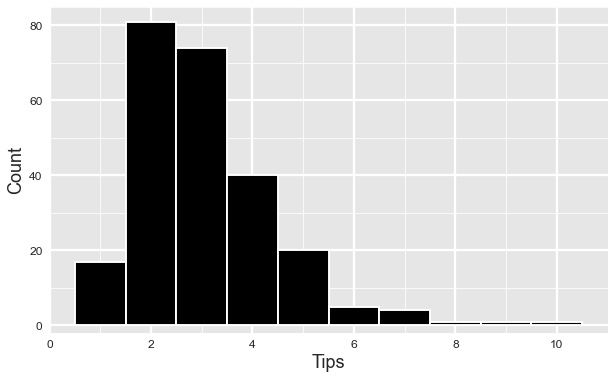

In [56]:
from matplotlib.ticker import AutoMinorLocator
sns.set_style("darkgrid", {"axes.facecolor": ".9"})

fig, ax = plt.subplots(figsize=(10,6))
ax.set_ylim(-2, 85)
ax.set_xlim(0, 11)
plt.hist(x=tip_data['tip'], color='black',bins=np.arange(12)-0.5,linewidth=1.9);

# LABELS
ax.set_xticks(np.arange(0, 12, 2))
ax.set_yticks(np.linspace(0, 80, num=5))

ax.tick_params(axis='both',direction='out', labelsize=12)
ax.set_xlabel('Tips',fontsize=18)
ax.set_ylabel('Count',fontsize=18)

# GRID
# ax.set_axisbelow(True)
ax.grid(which='major', color='white', linewidth=2.3)
ax.grid(which='minor', color='white', linewidth=0.8)

ax.minorticks_on()
ax.tick_params(which='minor', bottom=False, left=False)

# Only show minor gridlines once in between major gridlines.
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))

## Histogram: Tip Amounts over $0.10 Increments
Notes:

Right skewed

Higher frequency of tips around even rounded numbers (2, 2.50, 4, 4.50)


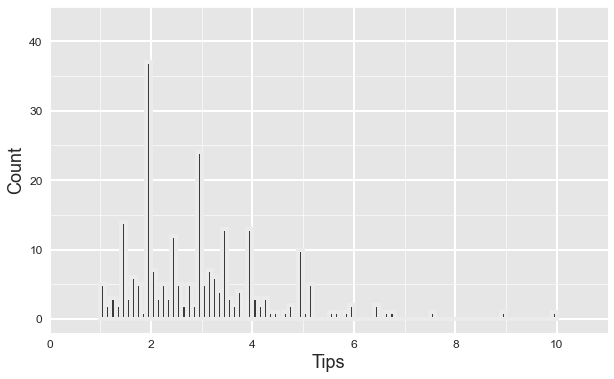

In [57]:
sns.set_style("darkgrid", {"axes.facecolor": ".9"})
fig, ax = plt.subplots(figsize=(10,6))

ax.set_ylim(-2,45)
ax.set_xlim(0,11)
ax.set_yticks(np.arange(0, 45, step=10))
sns.histplot(data=tip_data['tip'],color='black',edgecolor='#EBEBEB',linewidth=4, binwidth=0.1);

# LABELS
ax.tick_params(axis='both',direction='out', labelsize=12)
ax.set_xlabel('Tips',fontsize=18)
ax.set_ylabel('Count',fontsize=18)

# GRID
ax.set_axisbelow(True)
ax.grid(which='major', color='white', linewidth=2)
ax.grid(which='minor', color='white', linewidth=0.6)

ax.minorticks_on()
ax.tick_params(which='minor', bottom=False, left=False)

# Only show minor gridlines once in between major gridlines.
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))

## Scatterplot: Tips vs. Bill

Stronger correlation for lower bills, more dispersed correlation for higher bill

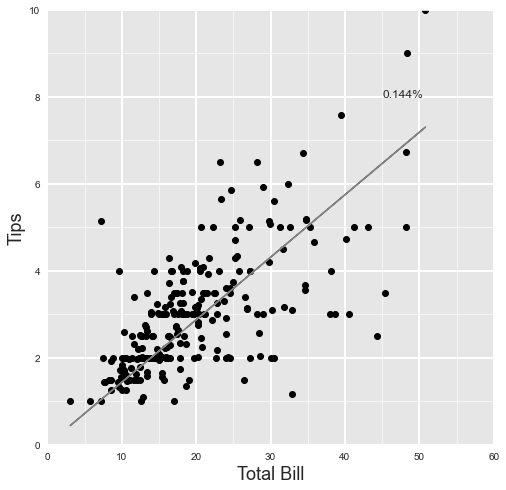

In [58]:
from sklearn.linear_model import LinearRegression

sns.set_style("darkgrid", {"axes.facecolor": ".9"})

fig, ax = plt.subplots(figsize=(8,8))
ax.set_xticks(np.arange(0,70,step=10))
ax.set_ylim(0,10)
ax.set_xlim(0,60)

plt.scatter(tip_data['total_bill'],tip_data['tip'], c='black')

# Calculating Regression
x = tip_data['total_bill'].values.reshape(len(tip_data['total_bill'].values),1)
y = tip_data['tip'].values
reg = LinearRegression(fit_intercept=False).fit(x,y)
predict = reg.predict(x)
plt.plot(x,predict, color='grey')
plt.text(45,8, str(round(reg.coef_[0],3))+'%', fontsize=12)

# LABELS
ax.set_xlabel('Total Bill',fontsize=18)
ax.set_ylabel('Tips',fontsize=18)

# GRID
ax.set_axisbelow(True)
ax.grid(which='major', color='white', linewidth=2)
ax.grid(which='minor', color='white', linewidth=0.6)

ax.minorticks_on()
ax.tick_params(which='minor', bottom=False, left=False)

# Only show minor gridlines once in between major gridlines.
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))

## Scatterplot: Tips vs. Bill, separated by payer gender and smoking section status

Stronger correlation in non smoking areas

Smokers show more variability than the non-smokers

Female non smokers had the most consistent tips

In [84]:
%matplotlib inline
import plotnine as p9
from plotnine import aes, geom_smooth, geom_point, facet_grid, scale_x_continuous, scale_y_continuous, xlab, ylab, theme

from scipy import stats
from plotnine.data import mtcars as df

(p9.ggplot(data=tip_data,
            mapping=p9.aes(x='total_bill',y='tip'))
            + p9.geom_smooth(method='lm',
            se=False, color='grey',
            fullrange=True,formula='y~0+x')
            + p9.geom_point(alpha=1)
            + p9.facet_grid("smoker ~ sex")
            + p9.scale_x_continuous(breaks=(0,10,20,30,40,50))
            + p9.scale_y_continuous(breaks=(0,2,4,6,8,10))
            + p9.labels.xlab('Total Bill')
            + p9.labels.ylab('Tips')
            + p9.theme(figure_size = (4, 4))
)

TypeError: set_ticks() takes 2 positional arguments but 3 were given